In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("bank_product_subscription_dataset.csv")

# Display the first 5 rows
df.head()

,client_id,age,age_group,gender,region,marital_status,education_level,employment_status,account_balance,credit_score,number_of_bank_products,contacts_during_campaign,days_since_last_contact,previous_campaign_success,preferred_contact_method,subscribed
0,B0001,59,51+,Male,South,Married,Bachelor,Full-time,39626.0,628,1,9,299,Yes,Email,0
1,B0002,35,26-35,Female,North,Divorced,College,Self-employed,22609.0,684,4,5,157,Yes,Phone,0
2,B0003,70,51+,Male,East,Married,College,Full-time,40068.0,659,4,6,316,Yes,Phone,0
3,B0004,60,51+,Male,South,Single,Master,Retired,56856.0,718,4,6,247,No,SMS,0
4,B0005,36,36-50,Male,North,Single,College,Full-time,20011.0,610,5,3,355,Yes,Phone,1


In [2]:
df.shape

(390, 16)

In [124]:
df.columns

Index(['client_id', 'age', 'age_group', 'gender', 'region', 'marital_status',
       'education_level', 'employment_status', 'account_balance',
       'credit_score', 'number_of_bank_products', 'contacts_during_campaign',
       'days_since_last_contact', 'previous_campaign_success',
       'preferred_contact_method', 'subscribed'],
      dtype='object')

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   client_id                  390 non-null    object 
 1   age                        390 non-null    int64  
 2   age_group                  390 non-null    object 
 3   gender                     390 non-null    object 
 4   region                     390 non-null    object 
 5   marital_status             390 non-null    object 
 6   education_level            390 non-null    object 
 7   employment_status          390 non-null    object 
 8   account_balance            375 non-null    float64
 9   credit_score               390 non-null    int64  
 10  number_of_bank_products    390 non-null    int64  
 11  contacts_during_campaign   390 non-null    int64  
 12  days_since_last_contact    390 non-null    int64  
 13  previous_campaign_success  390 non-null    object 

In [126]:
df.isnull().sum()

client_id                     0
age                           0
age_group                     0
gender                        0
region                        0
marital_status                0
education_level               0
employment_status             0
account_balance              15
credit_score                  0
number_of_bank_products       0
contacts_during_campaign      0
days_since_last_contact       0
previous_campaign_success     0
preferred_contact_method      0
subscribed                    0
dtype: int64

In [128]:
df.duplicated().sum()
df["subscribed"].value_counts()

subscribed
0    266
1    124
Name: count, dtype: int64

In [129]:
df["subscribed"].value_counts(normalize=True) * 100

subscribed
0    68.205128
1    31.794872
Name: proportion, dtype: float64

In [130]:
y = df["subscribed"]
# Define the input features
# We remove client_id because it is only an identifier
# We remove subscribed because it is the target variable
X = df.drop(columns=["client_id", "subscribed"])
# Display the first few rows of input features
X.head()

,age,age_group,gender,region,marital_status,education_level,employment_status,account_balance,credit_score,number_of_bank_products,contacts_during_campaign,days_since_last_contact,previous_campaign_success,preferred_contact_method
0,59,51+,Male,South,Married,Bachelor,Full-time,39626.0,628,1,9,299,Yes,Email
1,35,26-35,Female,North,Divorced,College,Self-employed,22609.0,684,4,5,157,Yes,Phone
2,70,51+,Male,East,Married,College,Full-time,40068.0,659,4,6,316,Yes,Phone
3,60,51+,Male,South,Single,Master,Retired,56856.0,718,4,6,247,No,SMS
4,36,36-50,Male,North,Single,College,Full-time,20011.0,610,5,3,355,Yes,Phone


In [131]:
fairness_columns = df[["gender", "age_group", "region"]]
# Remove these columns from the model input features
# These are demographic attributes and should not drive model predictions directly
X = X.drop(columns=["gender", "age_group", "region"])
X.head()

,age,marital_status,education_level,employment_status,account_balance,credit_score,number_of_bank_products,contacts_during_campaign,days_since_last_contact,previous_campaign_success,preferred_contact_method
0,59,Married,Bachelor,Full-time,39626.0,628,1,9,299,Yes,Email
1,35,Divorced,College,Self-employed,22609.0,684,4,5,157,Yes,Phone
2,70,Married,College,Full-time,40068.0,659,4,6,316,Yes,Phone
3,60,Single,Master,Retired,56856.0,718,4,6,247,No,SMS
4,36,Single,College,Full-time,20011.0,610,5,3,355,Yes,Phone


In [132]:
X["account_balance"] = X["account_balance"].fillna(X["account_balance"].median())
# Confirm that there are no more missing values
X.isnull().sum()

age                          0
marital_status               0
education_level              0
employment_status            0
account_balance              0
credit_score                 0
number_of_bank_products      0
contacts_during_campaign     0
days_since_last_contact      0
previous_campaign_success    0
preferred_contact_method     0
dtype: int64

In [133]:
X = pd.get_dummies(X, drop_first=True)
# Display the updated feature set
X.head()

,age,account_balance,credit_score,number_of_bank_products,contacts_during_campaign,days_since_last_contact,marital_status_Married,marital_status_Single,education_level_College,education_level_High School,education_level_Master,employment_status_Part-time,employment_status_Retired,employment_status_Self-employed,employment_status_Student,previous_campaign_success_Yes,preferred_contact_method_Phone,preferred_contact_method_SMS
0,59,39626.0,628,1,9,299,True,False,False,False,False,False,False,False,False,True,False,False
1,35,22609.0,684,4,5,157,False,False,True,False,False,False,False,True,False,True,True,False
2,70,40068.0,659,4,6,316,True,False,True,False,False,False,False,False,False,True,True,False
3,60,56856.0,718,4,6,247,False,True,False,False,True,False,True,False,False,False,False,True
4,36,20011.0,610,5,3,355,False,True,True,False,False,False,False,False,False,True,True,False


In [134]:
print("Total number of input features:", X.shape[1])
print("Feature names:", X.columns.tolist())

Total number of input features: 18
Feature names: ['age', 'account_balance', 'credit_score', 'number_of_bank_products', 'contacts_during_campaign', 'days_since_last_contact', 'marital_status_Married', 'marital_status_Single', 'education_level_College', 'education_level_High School', 'education_level_Master', 'employment_status_Part-time', 'employment_status_Retired', 'employment_status_Self-employed', 'employment_status_Student', 'previous_campaign_success_Yes', 'preferred_contact_method_Phone', 'preferred_contact_method_SMS']


In [135]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
# Also split fairness_columns together so they align with the test set
X_train, X_test, y_train, y_test, fairness_train, fairness_test = train_test_split(
X,
y,
fairness_columns,
test_size=0.2,
random_state=42,
stratify=y
)
# Check the size of each dataset
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (312, 18)
X_test shape: (78, 18)
y_train shape: (312,)
y_test shape: (78,)


In [136]:
from sklearn.tree import DecisionTreeClassifier
# Create a Decision Tree classification model
# max_depth=4 keeps the tree simple and helps prevent overfitting
# random_state=42 makes the result reproducible
model = DecisionTreeClassifier(max_depth=4, random_state=42)

In [137]:
# Train the model using the training data
# X_train contains the input features
# y_train contains the correct target values (subscribed or not)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [138]:
y_pred = model.predict(X_test)

In [139]:
comparison = pd.DataFrame({
"Actual Subscribed": y_test.values,
"Predicted Subscribed": y_pred
})
# Display the first 10 rows of the comparison table
comparison.head(10)

,Actual Subscribed,Predicted Subscribed
0,0,0
1,0,0
2,0,0
3,1,0
4,1,0
5,0,0
6,0,0
7,0,0
8,0,1
9,0,0


In [22]:
# Create a small DataFrame to compare actual and predicted values
# y_test contains the real churn values
# y_pred contains the model predictions
comparison = pd.DataFrame({
    "Actual subscribed": y_test.values,
    "Predicted subscribed": y_pred
})

# Display the first 10 rows of the comparison table
comparison.head(10)

,Actual subscribed,Predicted subscribed
0,0,0
1,0,0
2,0,0
3,1,0
4,1,0
5,0,0
6,0,0
7,0,0
8,0,1
9,0,0


In [140]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Use the trained model to make predictions on the test data
y_test_pred = model.predict(X_test)
# Calculate accuracy
# Accuracy shows the percentage of all correct predictions
accuracy = accuracy_score(y_test, y_test_pred)
# Calculate precision
# Precision shows how many predicted subscribers were actually subscribers
precision = precision_score(y_test, y_test_pred, zero_division=0)
# Calculate recall
# Recall shows how many actual subscribers were correctly identified by the model
recall = recall_score(y_test, y_test_pred, zero_division=0)
# Calculate F1-score
# F1-score is the balance between precision and recall

f1 = f1_score(y_test, y_test_pred, zero_division=0)
# Create a table to display the evaluation metrics
metrics_results = pd.DataFrame({
"Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
"Score": [accuracy, precision, recall, f1]
})
# Display the metrics table
metrics_results

,Metric,Score
0,Accuracy,0.653846
1,Precision,0.454545
2,Recall,0.400000
3,F1-Score,0.425532


In [141]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Use the trained model to predict subscription values for the test data
y_test_pred = model.predict(X_test)
# Create the confusion matrix by comparing actual values and predicted values
cm = confusion_matrix(y_test, y_test_pred)
# Extract the four values from the confusion matrix
tn, fp, fn, tp = cm.ravel()
# Create a DataFrame to show the confusion matrix in table format
cm_table = pd.DataFrame(
cm,

index=["Actual Not Subscribed (0)", "Actual Subscribed (1)"],
columns=["Predicted Not Subscribed (0)", "Predicted Subscribed (1)"]
)
# Display the confusion matrix table
cm_table

,Predicted Not Subscribed (0),Predicted Subscribed (1)
Actual Not Subscribed (0),41,12
Actual Subscribed (1),15,10


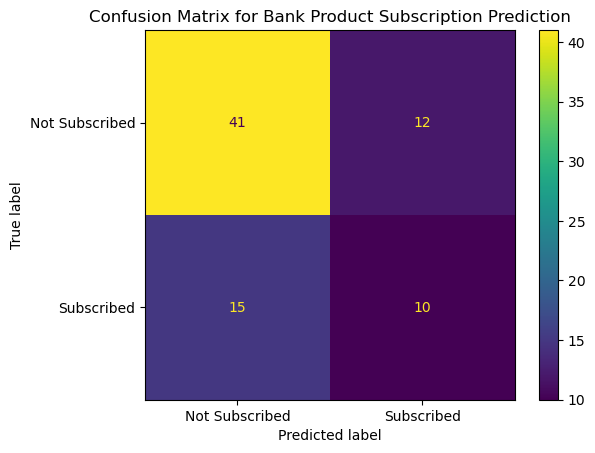

In [142]:
display_cm = ConfusionMatrixDisplay(
confusion_matrix=cm,
display_labels=["Not Subscribed", "Subscribed"]
)
# Plot the confusion matrix
display_cm.plot()
# Add a title to the plot
plt.title("Confusion Matrix for Bank Product Subscription Prediction")
# Show the plot
plt.show()

In [143]:
# Create a summary table for the four confusion matrix values
confusion_summary = pd.DataFrame({
"Type": ["True Negative", "False Positive", "False Negative", "True Positive"],
"Meaning": [

"The model correctly predicted that the client did NOT subscribe",
"The model predicted subscription, but the client did NOT subscribe",
"The model predicted no subscription, but the client DID subscribe",
"The model correctly predicted that the client DID subscribe"
],
"Value": [tn, fp, fn, tp]
})
# Display the summary table
confusion_summary

,Type,Meaning,Value
0,True Negative,The model correctly predicted that the client ...,41
1,False Positive,"The model predicted subscription, but the clie...",12
2,False Negative,"The model predicted no subscription, but the c...",15
3,True Positive,The model correctly predicted that the client ...,10


In [144]:
# Use the trained model to predict subscription values for the test data
y_test_pred = model.predict(X_test)
# Create a new DataFrame to compare actual and predicted subscription values
error_analysis = pd.DataFrame({
"Client ID": df.loc[y_test.index, "client_id"].values,
"Actual Subscribed": y_test.values,
"Predicted Subscribed": y_test_pred
})
# Create a new column to check whether each prediction is correct
error_analysis["Correct Prediction"] = (
error_analysis["Actual Subscribed"] == error_analysis["Predicted Subscribed"]
)
# Display the first 10 rows of the error analysis table
error_analysis.head(10)

,Client ID,Actual Subscribed,Predicted Subscribed,Correct Prediction
0,B0147,0,0,True
1,B0341,0,0,True
2,B0252,0,0,True
3,B0034,1,0,False
4,B0119,1,0,False
5,B0106,0,0,True
6,B0142,0,0,True
7,B0280,0,0,True
8,B0126,0,1,False
9,B0127,0,0,True


In [159]:
# Define a function to classify each prediction result
def classify_error(row):
    
    # True Negative: actual value is 0 and predicted value is 0
    if row["Actual Subscribed"] == 0 and row["Predicted Subscribed"] == 0:
        return "True Negative"
    
    # False Positive: actual value is 0 but predicted value is 1
    elif row["Actual Subscribed"] == 0 and row["Predicted Subscribed"] == 1:
        return "False Positive"
    
    # False Negative: actual value is 1 but predicted value is 0
    elif row["Actual Subscribed"] == 1 and row["Predicted Subscribed"] == 0:
        return "False Negative"
    
    # True Positive: actual value is 1 and predicted value is 1
    elif row["Actual Subscribed"] == 1 and row["Predicted Subscribed"] == 1:
        return "True Positive"

# Apply the function to each row and create a new column called Error Type
error_analysis["Error Type"] = error_analysis.apply(classify_error, axis=1)

# Display the first 10 rows with the error type
error_analysis.head(10)

,Client ID,Actual Subscribed,Predicted Subscribed,Correct Prediction,Error Type
0,B0147,0,0,True,True Negative
1,B0341,0,0,True,True Negative
2,B0252,0,0,True,True Negative
3,B0034,1,0,False,False Negative
4,B0119,1,0,False,False Negative
5,B0106,0,0,True,True Negative
6,B0142,0,0,True,True Negative
7,B0280,0,0,True,True Negative
8,B0126,0,1,False,False Positive
9,B0127,0,0,True,True Negative


In [160]:
# Count how many times each error type appears
error_counts = error_analysis["Error Type"].value_counts().reset_index()
# Rename the columns for better readability
error_counts.columns = ["Error Type", "Count"]
# Display the error count table
error_counts

,Error Type,Count
0,True Negative,41
1,False Negative,15
2,False Positive,12
3,True Positive,10


In [161]:
# Select only the rows where the model prediction was wrong
wrong_predictions = error_analysis[error_analysis["Correct Prediction"] == False]
# Display the wrong predictions
wrong_predictions.head(10)

,Client ID,Actual Subscribed,Predicted Subscribed,Correct Prediction,Error Type
3,B0034,1,0,False,False Negative
4,B0119,1,0,False,False Negative
8,B0126,0,1,False,False Positive
11,B0348,1,0,False,False Negative
13,B0274,1,0,False,False Negative
25,B0221,0,1,False,False Positive
26,B0085,0,1,False,False Positive
27,B0331,0,1,False,False Positive
29,B0081,0,1,False,False Positive
32,B0098,1,0,False,False Negative


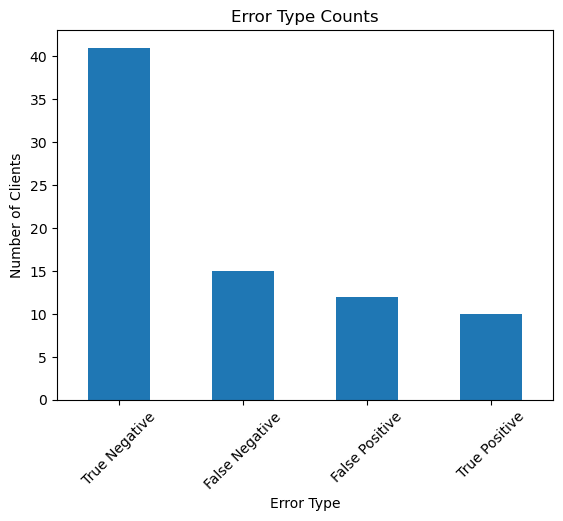

In [162]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt
# Create a simple bar chart for error types
error_counts.plot(
x="Error Type",
y="Count",
kind="bar",
legend=False
)
# Add a title to the chart
plt.title("Error Type Counts")
# Add a label for the x-axis
plt.xlabel("Error Type")
# Add a label for the y-axis
plt.ylabel("Number of Clients")
# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
# Show the chart
plt.show()

In [163]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
# Create a 5-fold cross-validation strategy
# n_splits=5 means the dataset will be divided into 5 parts

# shuffle=True means the data will be shuffled before splitting
# random_state=42 makes the result reproducible
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Apply cross-validation to the Decision Tree model
# X contains the input features
# y contains the target variable
# scoring="accuracy" means we evaluate the model using accuracy
cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
# Create a table to show the accuracy score for each fold
cv_results = pd.DataFrame({
"Fold": ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"],
"Accuracy": cv_scores
})
# Display the cross-validation results
cv_results

,Fold,Accuracy
0,Fold 1,0.692308
1,Fold 2,0.615385
2,Fold 3,0.692308
3,Fold 4,0.730769
4,Fold 5,0.679487


In [164]:
# Calculate the average accuracy across all folds
mean_cv_accuracy = cv_scores.mean()
# Calculate the standard deviation of accuracy across all folds
std_cv_accuracy = cv_scores.std()
# Create a summary table for cross-validation results
cv_summary = pd.DataFrame({
"Metric": ["Mean Cross-Validation Accuracy", "Standard Deviation"],
"Value": [mean_cv_accuracy, std_cv_accuracy]
})
# Display the summary table
cv_summary

,Metric,Value
0,Mean Cross-Validation Accuracy,0.682051
1,Standard Deviation,0.037510


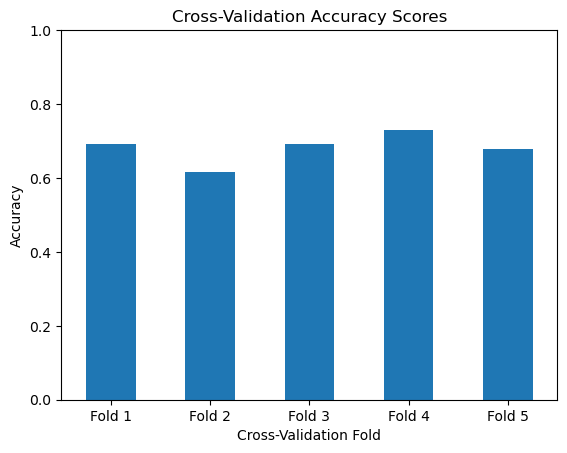

In [165]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt
# Create a bar chart for cross-validation accuracy scores
cv_results.plot(
x="Fold",
y="Accuracy",
kind="bar",

legend=False
)
# Add a title to the chart
plt.title("Cross-Validation Accuracy Scores")
# Add a label for the x-axis
plt.xlabel("Cross-Validation Fold")
# Add a label for the y-axis
plt.ylabel("Accuracy")
# Set the y-axis range from 0 to 1
plt.ylim(0, 1)
# Rotate x-axis labels for better readability
plt.xticks(rotation=0)
# Show the chart
plt.show()

In [166]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
# Load the dataset and preprocess again for this analysis
df = pd.read_csv("bank_product_subscription_dataset.csv")
# Define the target variable
y = df["subscribed"]
# Define the input features and remove identifier, target, and fairness columns
X = df.drop(columns=["client_id", "subscribed"])
X = X.drop(columns=["gender", "age_group", "region"])
# Fill missing values in account_balance with the median
X["account_balance"] = X["account_balance"].fillna(X["account_balance"].median())
# Convert categorical variables into numerical variables
X = pd.get_dummies(X, drop_first=True)
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42,
stratify=y
)


In [173]:
# Import DecisionTreeClassifier to create decision tree models
from sklearn.tree import DecisionTreeClassifier

# Create an empty list to store the results
depth_results = []

# Test different max_depth values from 1 to 10
for depth in range(1, 11):
    
    # Create a Decision Tree model with the current depth
    temp_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    # Train the model using the training data
    temp_model.fit(X_train, y_train)
    
    # Predict values for the training data
    train_pred = temp_model.predict(X_train)
    
    # Predict values for the testing data
    test_pred = temp_model.predict(X_test)
    
    # Calculate training accuracy
    train_acc = accuracy_score(y_train, train_pred)
    
    # Calculate testing accuracy
    test_acc = accuracy_score(y_test, test_pred)
    
    # Save the depth, training accuracy, and testing accuracy
    depth_results.append([depth, train_acc, test_acc])

# Convert the results into a DataFrame
depth_results_df = pd.DataFrame(
    depth_results,
    columns=["Max Depth", "Training Accuracy", "Testing Accuracy"]
)

# Display the results table
depth_results_df

,Max Depth,Training Accuracy,Testing Accuracy
0,1,0.682692,0.679487
1,2,0.727564,0.641026
2,3,0.762821,0.717949
3,4,0.804487,0.653846
4,5,0.865385,0.666667
5,6,0.919872,0.653846
6,7,0.945513,0.641026
7,8,0.961538,0.666667
8,9,0.983974,0.589744
9,10,0.990385,0.615385


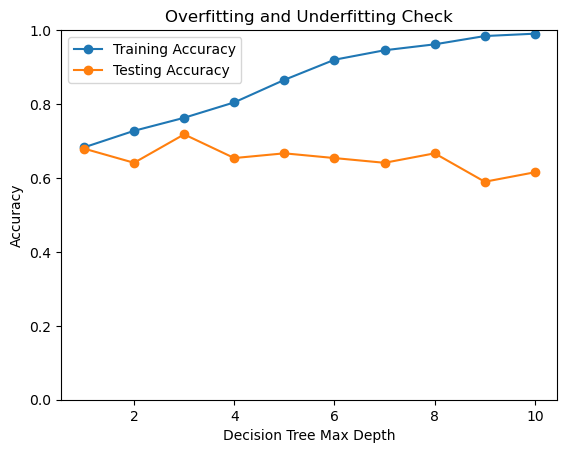

In [174]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Plot training accuracy for different tree depths
plt.plot(
    depth_results_df["Max Depth"],
    depth_results_df["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

# Plot testing accuracy for different tree depths
plt.plot(
    depth_results_df["Max Depth"],
    depth_results_df["Testing Accuracy"],
    marker="o",
    label="Testing Accuracy"
)

# Add a title to the chart
plt.title("Overfitting and Underfitting Check")

# Add a label for the x-axis
plt.xlabel("Decision Tree Max Depth")

# Add a label for the y-axis
plt.ylabel("Accuracy")

# Set the y-axis range from 0 to 1
plt.ylim(0, 1)

# Add a legend to explain the two lines
plt.legend()

# Show the chart
plt.show()

In [175]:
# Get the importance score of each feature from the trained Decision Tree model
feature_importance_values = model.feature_importances_
# Get the feature names from X_train
feature_names = X_train.columns
# Create a DataFrame to store feature names and their importance scores
feature_importance_df = pd.DataFrame({
"Feature": feature_names,
"Importance": feature_importance_values
})
# Sort the features from most important to least important
feature_importance_df = feature_importance_df.sort_values(
by="Importance",
ascending=False
).reset_index(drop=True)
# Display the feature importance table
feature_importance_df

,Feature,Importance
0,days_since_last_contact,0.278130
1,account_balance,0.236343
2,number_of_bank_products,0.152201
3,previous_campaign_success_Yes,0.136276
4,credit_score,0.103371
5,contacts_during_campaign,0.059049
6,preferred_contact_method_SMS,0.034631
7,employment_status_Retired,0.000000
8,preferred_contact_method_Phone,0.000000
9,employment_status_Student,0.000000


In [177]:
top_features = feature_importance_df.head(10)
top_features

,Feature,Importance
0,days_since_last_contact,0.278130
1,account_balance,0.236343
2,number_of_bank_products,0.152201
3,previous_campaign_success_Yes,0.136276
4,credit_score,0.103371
5,contacts_during_campaign,0.059049
6,preferred_contact_method_SMS,0.034631
7,employment_status_Retired,0.000000
8,preferred_contact_method_Phone,0.000000
9,employment_status_Student,0.000000


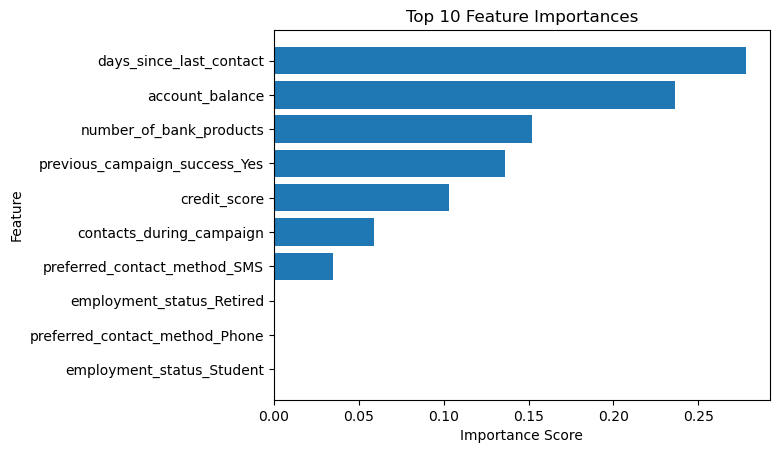

In [178]:
import matplotlib.pyplot as plt
# Create a horizontal bar chart for the top 10 important features
plt.barh(
top_features["Feature"],
top_features["Importance"]
)
# Add a title to the chart
plt.title("Top 10 Feature Importances")
# Add a label for the x-axis
plt.xlabel("Importance Score")
# Add a label for the y-axis
plt.ylabel("Feature")
# Show the most important feature at the top
plt.gca().invert_yaxis()
# Show the chart
plt.show()

In [179]:
!pip install shap

In [180]:
import shap
import matplotlib.pyplot as plt
# Initialize SHAP JavaScript visualization for Jupyter Notebook
shap.initjs()

In [181]:
# Create a SHAP explainer for the trained Decision Tree model
explainer = shap.TreeExplainer(model)
# Calculate SHAP values for the test data
shap_values = explainer.shap_values(X_test)
# Check the type of SHAP values
type(shap_values)

numpy.ndarray

In [187]:
if isinstance(shap_values, list):
    
    # If SHAP returns a list, select index 1 for the churn class
    shap_values_class1 = shap_values[1]
    
    # Select the expected value for the churn class
    base_value_class1 = explainer.expected_value[1]

else:
    
    # If SHAP returns an array with three dimensions, select class 1
    shap_values_class1 = shap_values[:, :, 1]
    
    # Select the expected value for class 1
    base_value_class1 = explainer.expected_value[1]

# Display the shape of SHAP values for class 1
shap_values_class1.shape

(78, 18)

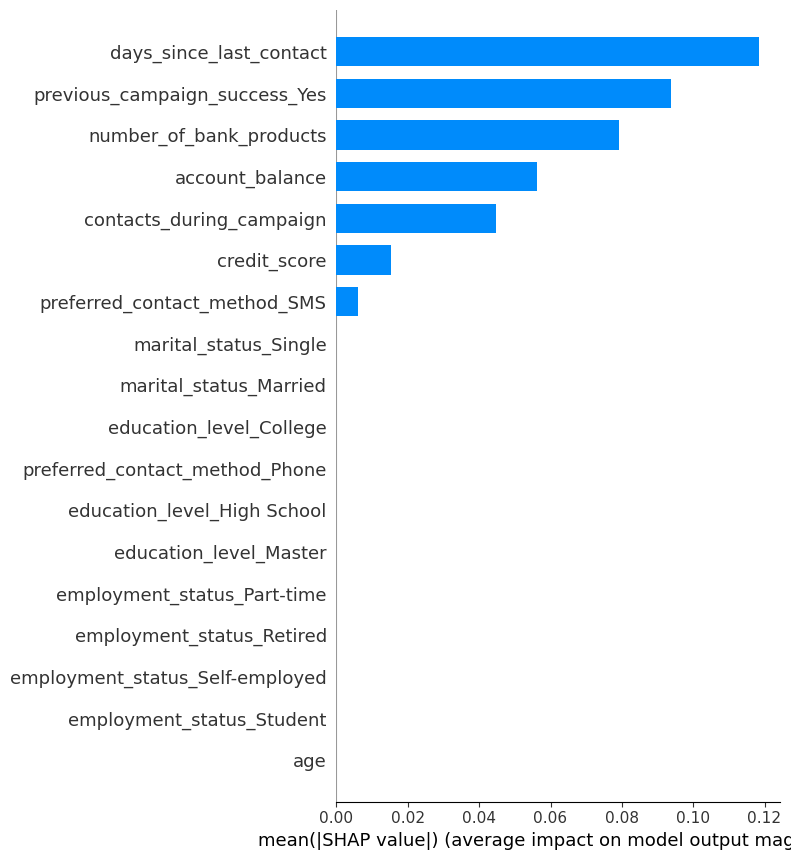

In [189]:
 #Create a SHAP summary bar plot
# This plot shows the most important features based on SHAP values
shap.summary_plot(
shap_values_class1,
X_test,
plot_type="bar"
)

In [190]:
# Select one client from the test dataset
client_index = 0
# Get the feature values for this client
client_data = X_test.iloc[client_index]
# Get the SHAP values for this client
client_shap_values = shap_values_class1[client_index]
# Create a DataFrame to show each feature and its SHAP contribution
client_explanation = pd.DataFrame({
"Feature": X_test.columns,
"Feature Value": client_data.values,
"SHAP Value": client_shap_values
})
# Create a column with absolute SHAP values to sort by importance
client_explanation["Absolute SHAP Value"] = client_explanation["SHAP Value"].abs()
# Sort features by their absolute SHAP impact
client_explanation = client_explanation.sort_values(
by="Absolute SHAP Value",
ascending=False
).reset_index(drop=True)
# Display the explanation table for this client
client_explanation.head(10)

,Feature,Feature Value,SHAP Value,Absolute SHAP Value
0,contacts_during_campaign,8,-0.136118,0.136118
1,days_since_last_contact,277,-0.103555,0.103555
2,account_balance,16889.0,-0.053162,0.053162
3,previous_campaign_success_Yes,False,-0.052123,0.052123
4,number_of_bank_products,5,0.046798,0.046798
5,credit_score,781,-0.002927,0.002927
6,preferred_contact_method_SMS,False,0.001323,0.001323
7,employment_status_Retired,False,0.000000,0.000000
8,preferred_contact_method_Phone,True,0.000000,0.000000
9,employment_status_Student,False,0.000000,0.000000


In [191]:
 # Get the actual subscription value for this client
actual_value = y_test.iloc[client_index]
# Get the predicted subscription value for this client
predicted_value = y_test_pred[client_index]
# Create a small table to compare actual and predicted subscription
single_client_result = pd.DataFrame({
"Actual Subscribed": [actual_value],
"Predicted Subscribed": [predicted_value]
})
# Display the result
single_client_result

,Actual Subscribed,Predicted Subscribed
0,0,0


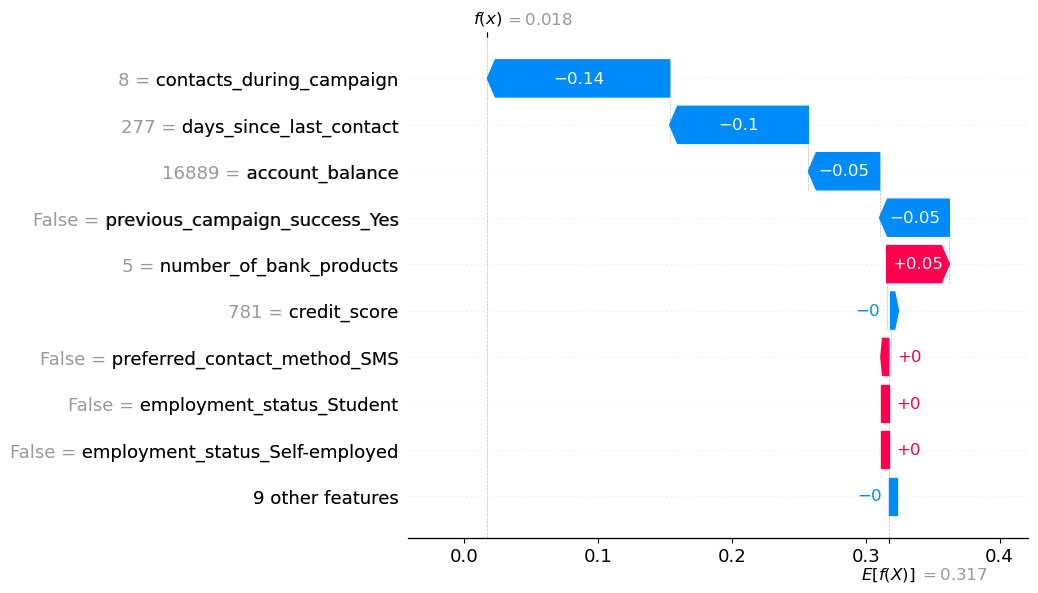

In [192]:
 # Create a SHAP explanation object for one client
single_client_explanation = shap.Explanation(
values=client_shap_values,
base_values=base_value_class1,
data=client_data,
feature_names=X_test.columns
)
# Create a waterfall plot to explain this client prediction
shap.plots.waterfall(single_client_explanation)

In [193]:
# Install LIME if it is not already installed
# Run this cell only if you get an error that says: No module named 'lime'
!pip install lime

In [194]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer

In [195]:
# Convert X_train to float format for LIME
X_train_lime = X_train.astype(float)
# Convert X_test to float format for LIME
X_test_lime = X_test.astype(float)
# Store the feature names
feature_names = X_train_lime.columns.tolist()
# Define class names for the target variable
class_names = ["Not Subscribed", "Subscribed"]

In [196]:
 # Create a LIME explainer for tabular data
lime_explainer = LimeTabularExplainer(
# Use the training data as the background data for LIME
training_data=X_train_lime.values,
# Provide the feature names
feature_names=feature_names,
# Provide the class names
class_names=class_names,
# Set the mode to classification because subscribed is a classification problem
mode="classification",
# Discretize continuous variables to make explanations easier to understand
discretize_continuous=True
)

In [197]:
# Select one client from the test data
client_index = 0
# Get the selected client's feature values
client_instance = X_test_lime.iloc[client_index]
# Display the selected client data
client_instance

age                                   60.0
account_balance                    16889.0
credit_score                         781.0
number_of_bank_products                5.0
contacts_during_campaign               8.0
days_since_last_contact              277.0
marital_status_Married                 0.0
marital_status_Single                  0.0
education_level_College                0.0
education_level_High School            0.0
education_level_Master                 1.0
employment_status_Part-time            0.0
employment_status_Retired              0.0
employment_status_Self-employed        0.0
employment_status_Student              0.0
previous_campaign_success_Yes          0.0
preferred_contact_method_Phone         1.0
preferred_contact_method_SMS           0.0
Name: 146, dtype: float64

In [198]:
 # Generate a LIME explanation for the selected client
lime_explanation = lime_explainer.explain_instance(
# The selected client data
data_row=client_instance.values,
# The model prediction probability function
predict_fn=model.predict_proba,
# Show the top 10 most important features for this explanation
num_features=10
)

C:\Users\luqma\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [199]:
# Get the actual subscription value for this client
actual_value = y_test.iloc[client_index]
# Get the predicted subscription value for this client
predicted_value = model.predict(X_test_lime.iloc[[client_index]])[0]
# Get the predicted probabilities for Not Subscribed and Subscribed
predicted_probabilities = model.predict_proba(X_test_lime.iloc[[client_index]])[0]
# Create a small table to show the result
lime_prediction_result = pd.DataFrame({
"Actual Subscribed": [actual_value],
"Predicted Subscribed": [predicted_value],
"Probability of Not Subscribed": [predicted_probabilities[0]],
"Probability of Subscribed": [predicted_probabilities[1]]
})
# Display the result
lime_prediction_result

,Actual Subscribed,Predicted Subscribed,Probability of Not Subscribed,Probability of Subscribed
0,0,0,0.982456,0.017544


In [200]:
# Convert the LIME explanation into a readable table
lime_explanation_table = pd.DataFrame(
lime_explanation.as_list(),
columns=["Feature Condition", "Contribution"]
)
# Display the LIME explanation table
lime_explanation_table

,Feature Condition,Contribution
0,previous_campaign_success_Yes <= 0.00,-0.137968
1,days_since_last_contact > 269.00,-0.126527
2,number_of_bank_products > 4.00,0.101651
3,contacts_during_campaign > 7.00,-0.069809
4,preferred_contact_method_SMS <= 0.00,0.021816
5,employment_status_Student <= 0.00,0.010965
6,16690.00 < account_balance <= 37903.00,0.009403
7,credit_score > 725.25,-0.008014
8,marital_status_Single <= 0.00,-0.007495
9,0.00 < preferred_contact_method_Phone <= 1.00,0.004323


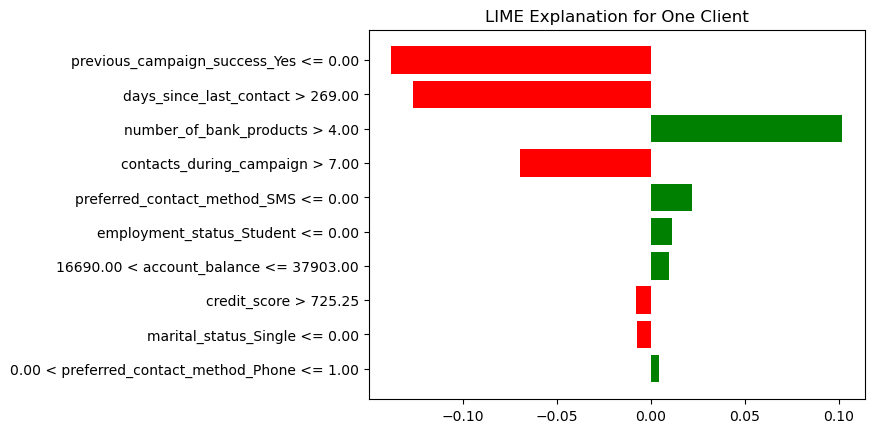

In [201]:
 #Create a LIME explanation chart
fig = lime_explanation.as_pyplot_figure()
# Add a title to the chart
plt.title("LIME Explanation for One Client")
# Show the chart
plt.show()

In [202]:
 #Show the LIME explanation inside the notebook
from IPython.display import display, HTML
# Convert the LIME explanation to HTML format
lime_html = lime_explanation.as_html()
# Display the LIME explanation as HTML inside the notebook
display(HTML(lime_html))

In [206]:
# Use the trained model to predict subscription values for the test data
y_test_pred = model.predict(X_test)
# Select fairness-related columns for the same clients in the test data
fairness_data = df.loc[y_test.index,["client_id", "gender", "age_group", "region"]]
# Add the actual subscription values to the fairness table
fairness_data["Actual Subscribed"] = y_test.values
# Add the predicted subscription values to the fairness table
fairness_data["Predicted Subscribed"] = y_test_pred
# Create a column to show whether each prediction is correct
fairness_data["Correct Prediction"] = (
fairness_data["Actual Subscribed"] == fairness_data["Predicted Subscribed"]
)
# Display the first 10 rows
fairness_data.head(10)

,client_id,gender,age_group,region,Actual Subscribed,Predicted Subscribed,Correct Prediction
146,B0147,Male,51+,South,0,0,True
340,B0341,Female,18-25,East,0,0,True
251,B0252,Male,51+,West,0,0,True
33,B0034,Female,26-35,North,1,0,False
118,B0119,Male,18-25,North,1,0,False
105,B0106,Female,51+,East,0,0,True
141,B0142,Female,26-35,South,0,0,True
279,B0280,Male,51+,North,0,0,True
125,B0126,Male,26-35,North,0,1,False
126,B0127,Female,26-35,West,0,0,True


In [209]:
 # Define a function to summarize model performance by group
def fairness_summary(group_column):
# Group the fairness data by the selected group column
   summary = fairness_data.groupby(group_column).agg(
# Count how many clients exist in each group
Number_of_Clients=("client_id", "count"),
# Calculate the actual subscription rate in each group
Actual_Subscription_Rate=("Actual Subscribed", "mean"),
# Calculate the predicted subscription rate in each group
Predicted_Subscription_Rate=("Predicted Subscribed", "mean"),
# Calculate the accuracy in each group
Accuracy=("Correct Prediction", "mean")
).reset_index()
# Return the summary table
   return summary

In [210]:
 # Create a fairness summary by gender
gender_fairness = fairness_summary("gender")
# Display the fairness summary by gender
gender_fairness

,gender,Number_of_Clients,Actual_Subscription_Rate,Predicted_Subscription_Rate,Accuracy
0,Female,47,0.319149,0.212766,0.638298
1,Male,31,0.322581,0.387097,0.677419


In [211]:
# Create a fairness summary by age group
age_group_fairness = fairness_summary("age_group")
# Display the fairness summary by age group
age_group_fairness

,age_group,Number_of_Clients,Actual_Subscription_Rate,Predicted_Subscription_Rate,Accuracy
0,18-25,20,0.150000,0.150000,0.700000
1,26-35,16,0.375000,0.312500,0.437500
2,36-50,15,0.333333,0.333333,0.733333
3,51+,27,0.407407,0.333333,0.703704


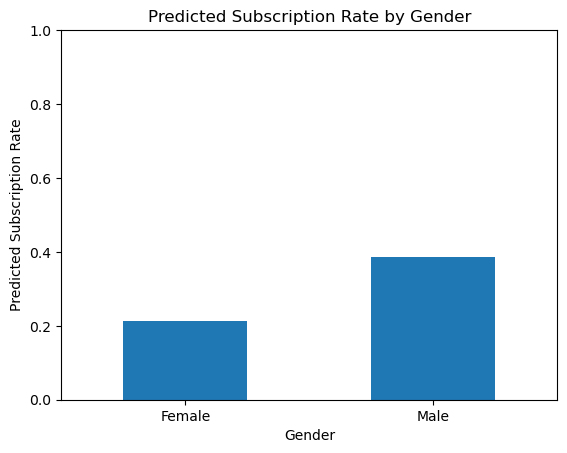

In [213]:
import matplotlib.pyplot as plt
# Create a simple bar chart for predicted subscription rate by gender
gender_fairness.plot(
x="gender",
y="Predicted_Subscription_Rate",
kind="bar",
legend=False
)
# Add a title to the chart
plt.title("Predicted Subscription Rate by Gender")
# Add a label for the x-axis
plt.xlabel("Gender")
# Add a label for the y-axis
plt.ylabel("Predicted Subscription Rate")
# Set y-axis from 0 to 1
plt.ylim(0, 1)
# Rotate x-axis labels
plt.xticks(rotation=0)
# Show the chart
plt.show()

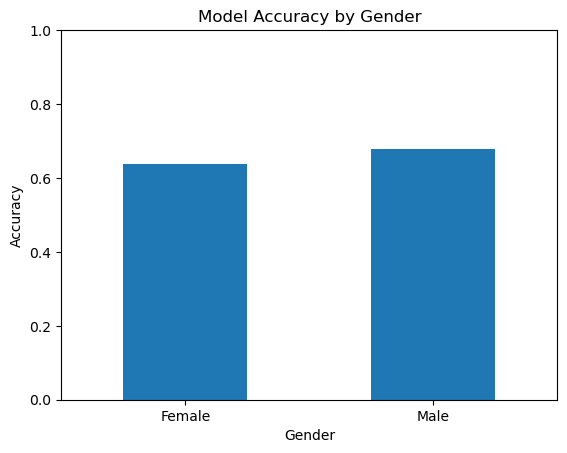

In [214]:
# Create a simple bar chart for accuracy by gender
gender_fairness.plot(
x="gender",
y="Accuracy",
kind="bar",
legend=False
)
# Add a title to the chart
plt.title("Model Accuracy by Gender")
# Add a label for the x-axis
plt.xlabel("Gender")
# Add a label for the y-axis
plt.ylabel("Accuracy")
# Set y-axis from 0 to 1
plt.ylim(0, 1)
# Rotate x-axis labels
plt.xticks(rotation=0)
# Show the chart
plt.show()

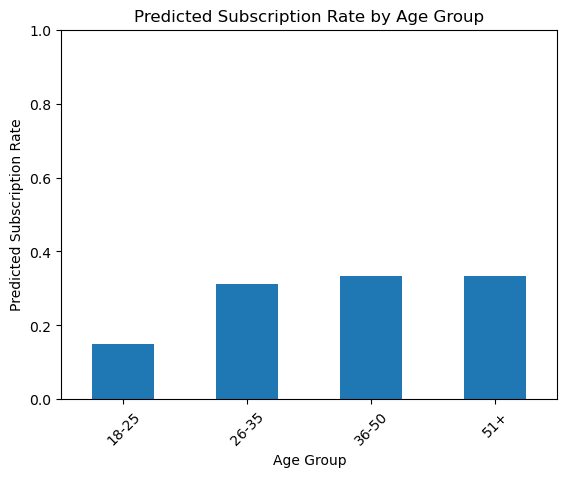

In [215]:
 # Create a simple bar chart for predicted subscription rate by age group
age_group_fairness.plot(
x="age_group",
y="Predicted_Subscription_Rate",
kind="bar",
legend=False
)
# Add a title to the chart
plt.title("Predicted Subscription Rate by Age Group")
# Add a label for the x-axis
plt.xlabel("Age Group")
# Add a label for the y-axis
plt.ylabel("Predicted Subscription Rate")
# Set y-axis from 0 to 1
plt.ylim(0, 1)
# Rotate x-axis labels
plt.xticks(rotation=45)
# Show the chart
plt.show()


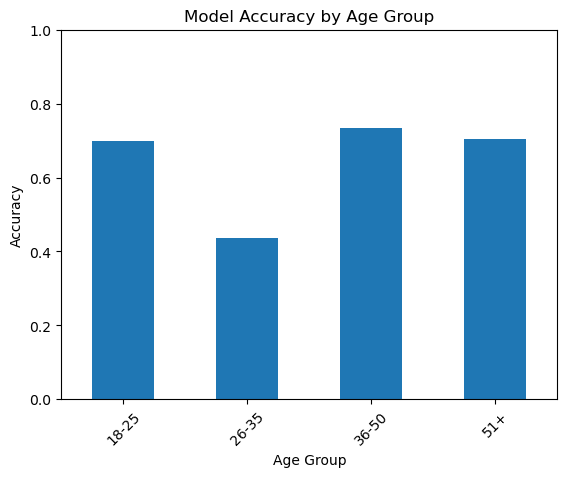

In [216]:
# Create a simple bar chart for accuracy by age group
age_group_fairness.plot(
x="age_group",
y="Accuracy",
kind="bar",
legend=False
)
# Add a title to the chart
plt.title("Model Accuracy by Age Group")
# Add a label for the x-axis
plt.xlabel("Age Group")
# Add a label for the y-axis
plt.ylabel("Accuracy")
# Set y-axis from 0 to 1
plt.ylim(0, 1)
# Rotate x-axis labels
plt.xticks(rotation=45)
# Show the chart
plt.show()


In [218]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# Predict subscription values for training data
y_train_pred = model.predict(X_train)
# Predict subscription values for testing data
y_test_pred = model.predict(X_test)
# Calculate training accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
# Calculate testing accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
# Calculate precision
precision = precision_score(y_test, y_test_pred, zero_division=0)
# Calculate recall
recall = recall_score(y_test, y_test_pred, zero_division=0)
# Calculate F1-score
f1 = f1_score(y_test, y_test_pred, zero_division=0)
# Create confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
# Extract True Negative, False Positive, False Negative, and True Positive
tn, fp, fn, tp = cm.ravel()
# Create a final business summary table
business_summary = pd.DataFrame({
"Result": [
"Training Accuracy",
"Testing Accuracy",
"Precision",
"Recall",
"F1-Score",
"True Negative",
"False Positive",
"False Negative",
"True Positive"
],
"Value": [
train_accuracy,
test_accuracy,
precision,
recall,
f1,
tn,
fp,
fn,
tp
]
})
# Display the business summary table
business_summary


,Result,Value
0,Training Accuracy,0.804487
1,Testing Accuracy,0.653846
2,Precision,0.454545
3,Recall,0.400000
4,F1-Score,0.425532
5,True Negative,41.000000
6,False Positive,12.000000
7,False Negative,15.000000
8,True Positive,10.000000


In [ ]:
print("Model Evaluation Summary")
print("--"*50)
print('''The decision tree model predicts whether a bank client to a bank product 
         after being contacted in a direct marketing campaign.

        The model achieves a testing accuracy of 65%, which is actually below the 
        baseline of 68%. Precision is 45%, Recall is 40%, and F1 is 42%. These are 
        weak results for a production marketing system. 
        
        Recall is the most important metric. The bank's goal is to identify real 
        subscribers so they can be targeted in the campaign. The current Recall of 40%
        means the model is missing 60% of the clients it should be finding.

        False negatives are the dominant and most damaging error type. Out of 25 
        actual subscribers in the test set, the model correctly identified only 10, and 
        missed 15. 

        The model shows overfitting. Training accuracy is 80% vs testing accuracy of 
        65%. There is a 15-point gap. While testing accuracy does not improve, the 
        model is memorizing from the training data rather than learning from the pattern. 
        
        Number_of_bank_products, account_balance, days_since_last_contact and 
        Previous campaign success is an important prediction.

        SHAP confirmed that recent contact and financial activity drive the model's 
        Predictions are both global and individual. LIME provided readable, client-level
        explanations that allow stakeholders to understand predictions and support 
        transparency. 

        The model performs differently across gender and the age gap due to class imbalance.
        These differences could lead to systematic unfairness that affects protected groups. 

        
        Final Recommendation: The model is suitable, but still needs some significant
        improvements before implementing it.
        Address the class imbalance, which will improve Recall.
        Apply for